In [15]:
import torch
import matplotlib
import matplotlib.pyplot as plt
from model import UNet
import time
from IPython.display import clear_output, display

In [33]:
net = UNet()
net.load_state_dict(torch.load("ckpt.pt"))
net.eval()

UNet(
  (t_projection): Linear(in_features=1, out_features=1024, bias=True)
  (initial): Sequential(
    (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): GroupNorm(8, 64, eps=1e-05, affine=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (downsamples): ModuleList(
    (0): Downsample(
      (model): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (2): LeakyReLU(negative_slope=0.01)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 128, eps=1e-05, affine=True)
        (5): LeakyReLU(negative_slope=0.01)
      )
      (down): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Downsample(
      

In [46]:
noise = torch.randn((1, 3, 32, 32))

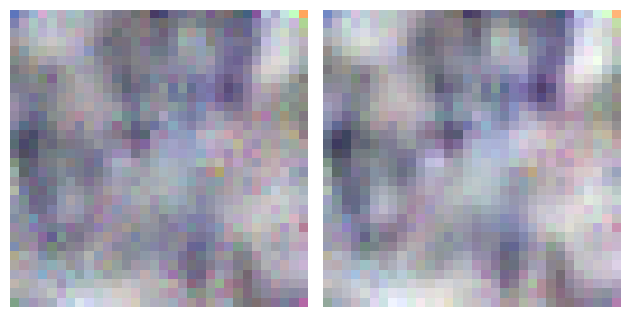

In [47]:
sample = noise
t = torch.tensor([0.0]).view(-1, 1, 1, 1)
# print(noise.shape, t.shape)

N = [3, 50, ]
# N = [1, 3]

# fig, ax = plt.subplots()

ends = []

with torch.no_grad():
    for j in N:
        sample = noise
        t = torch.tensor([0.0]).view(-1, 1, 1, 1)
        for i in range(j):
            # clear_output(wait=True)
            t = torch.tensor([i / j]).view(-1, 1, 1, 1)
            sample = sample + net(sample, t) * (1 / j)

            
            # print(sample.shape)

            # ax.cla()
            # ax.imshow(sample.squeeze().permute(1,2,0))

            # display(fig)
            # time.sleep(.3)

            print(f"{i/j*100:.2f}%", end='\r')

        ends.append(sample)

fig, ax = plt.subplots(1, len(N))

for i in range(len(N)):
    end = (ends[i] / 2.0 + .5).clamp(0.0, 1.0)
    ax[i].imshow(end.squeeze().permute(1,2,0))
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
device = 'cpu'

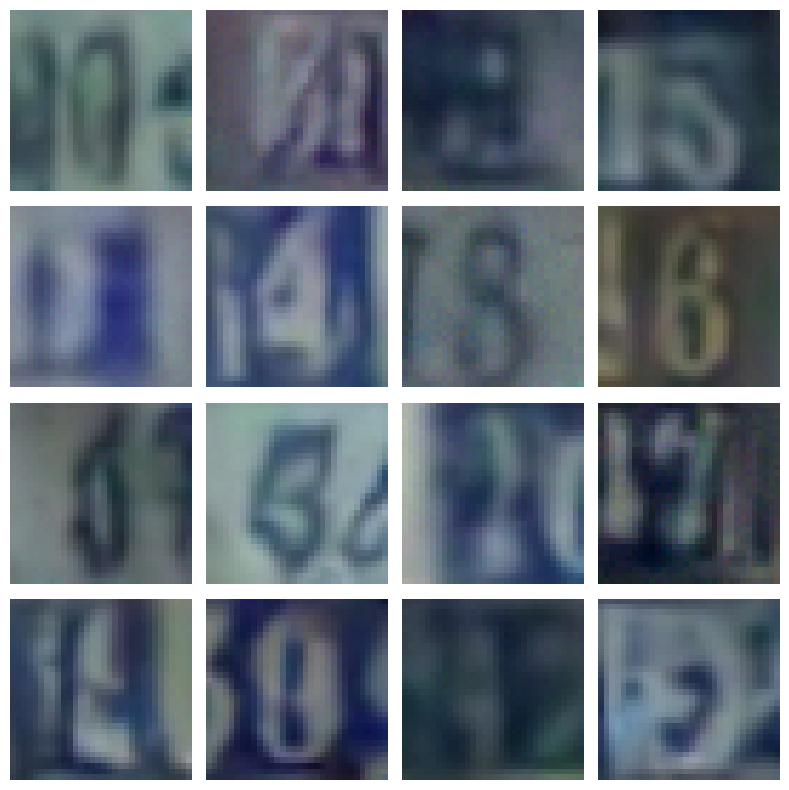

90.00%


In [ ]:
B = 16
N = 25
noise = torch.randn((B, 3, 32, 32), device=device)  
sample = noise

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
ims = []
for ax in axes.flat:
    im = ax.imshow(torch.zeros(32, 32, 3))
    ax.axis('off')
    ims.append(im)
plt.tight_layout()

with torch.no_grad():
    for step in range(N):
        t = torch.full((B, 1, 1, 1), step / N, device=sample.device)
        sample = sample + net(sample, t) * (1 / N)
        
        grid = (sample / 2.0 + 0.5).clamp(0.0, 1.0).cpu().permute(0, 2, 3, 1).numpy()
        
        for j, im in enumerate(ims):
            im.set_data(grid[j])
        
        clear_output(wait=True)
        display(fig)
        print(f"{step/N*100:.2f}%")

plt.close(fig)  